In [1]:
import numpy as np
import matplotlib.pyplot as plt
import process_data as pd
import frequency_func as ff
from scipy.optimize import curve_fit
import pandas
import math
plt.rcParams['text.usetex'] = True
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
# files not used: 97-82(kswap), 104(km=3ke), 107(thermal,km=3ke)
# files that need appending: 96-72,97-82,98-86,99-87,100-88,103-74
ke=0.9
km=1.8
B=np.array([0.8,0,-0.6])
B_lin=np.linspace(0,1,5)
ax_lin=np.linspace(-1,1,5)
A=0.9/np.max((ke**3,km**3))
eps0=math.log(ke/km)*3/(ke-km)
e_i=45

In [3]:
# in for loop of files, save: radius, time, P vectors, B_angle, f, eps, frequency
# split by variable

In [64]:
# split by if append or not
datas=[]
combine=np.array([['72-QKE_32_1_coh8','96-72-QKE_32_1_coh8'],
          ['86-QKE_32_1_mix03','98-86-QKE_32_1_mix03'],
          ['87-QKE_32_1_mix01','99-87-QKE_32_1_mix01'],
          ['88-QKE_32_1_mix001','100-88-QKE_32_1_mix001'],
          ['74-QKE_32_atm','103-74-QKE_32_atm'],
          ['82-QKE_32_1_swap','97-82-QKE_32_1_swap']])
files=np.array(['75-QKE_32_10','76-QKE_32_4','77-QKE_32_3','78-QKE_32_2','79-QKE_32_05','80-QKE_32_025',
                '83-QKE_30_1','84-QKE_34_1',
                '85-QKE_32_1_mix06','89-QKE_36_1','90-QKE_40_1','91-QKE_25_1','92-QKE_20_1','101-QKE_32_1_150bins',
                '104-QKE_32_1_km3','107-thermal_km3'])
for i in range(len(combine)):
    d1=pd.make_data_dictionary('../QKE_data/'+combine[i,0]+'.csv', '../QKE_data/'+combine[i,0]+'-eps.csv')
    d2=pd.make_data_dictionary('../QKE_data/'+combine[i,1]+'.csv', '../QKE_data/'+combine[i,1]+'-eps.csv')
    data=pd.combine_dictionary(d1, d2)
    print(i,combine[i,0])
#     print(len(data['time']))
    datas.append(data)
for i in range(len(files)):
    data=pd.make_data_dictionary('../QKE_data/'+files[i]+'.csv', '../QKE_data/'+files[i]+'-eps.csv')
    print(i+len(combine),files[i])
#     print(len(data['time']))
    datas.append(data)

0 72-QKE_32_1_coh8
1 86-QKE_32_1_mix03
2 87-QKE_32_1_mix01
3 88-QKE_32_1_mix001
4 74-QKE_32_atm
5 82-QKE_32_1_swap
6 75-QKE_32_10
7 76-QKE_32_4
8 77-QKE_32_3
9 78-QKE_32_2
10 79-QKE_32_05
11 80-QKE_32_025
12 83-QKE_30_1
13 84-QKE_34_1
14 85-QKE_32_1_mix06
15 89-QKE_36_1
16 90-QKE_40_1
17 91-QKE_25_1
18 92-QKE_20_1
19 101-QKE_32_1_150bins
20 104-QKE_32_1_km3
21 107-thermal_km3


In [65]:
#indexes need updating also check for hardcoding
# Tcm_names=(['72-QKE_32_1_coh8','83-QKE_30_1','84-QKE_34_1','89-QKE_36_1','90-QKE_40_1','91-QKE_25_1','92-QKE_20_1'])
Tcms=([32,30,34,36,40,25,20])
Tcm_ind=(0,12,13,15,16,17,18)
# Dm2_names=(['72-QKE_32_1_coh8','74-QKE_32_atm','103-74-QKE_32_atm','75-QKE_32_10','76-QKE_32_4','77-QKE_32_3','78-QKE_32_2','79-QKE_32_05','80-QKE_32_025'])
Dm2_ind=([0,4,6,7,8,9,10,11])
Dm2s=([1e-18,76e-18,10e-18,4e-18,3e-18,2e-18,0.5e-18,0.25e-18])
# mix_names=(['72-QKE_32_1_coh8','85-QKE_32_1_mix06','86-QKE_32_1_mix03','98-86-QKE_32_1_mix03','87-QKE_32_1_mix01','99-87-QKE_32_1_mix01','88-QKE_32_1_mix001','100-88-QKE_32_1_mix001'])
mix_ind=([0,1,2,3,14])
mixs=np.array((0.8,0.3,0.1,0.01,0.6))
eps_ind=([0,19])
k_ind=([0,5,20])
ks=np.array([[0.9,1.8,0.9],[1.8,0.9,2.7]]) #(ke,km)

In [66]:
e_i=45
epss=[]
ws=[]
times=[]
fvs=[]
Pxs=[]
Pzs=[]
Bs=[]
radii=[]
pts=[]
afs=[]
switchs=[]

for i in range(len(datas)):
    epss.append(datas[i]['eps'])
    ws.append(datas[i]['w'])
    times.append(datas[i]['time'])
    fvs.append(datas[i]['f'])
    P0, Px, Py, Pz = pd.make_P(datas[i]['rho'])
    P0bar, Pxbar, Pybar, Pzbar = pd.make_P(datas[i]['rhobar'])
    Pxs.append(Px)
    Pzs.append(Pz)
    
    S=np.array([(P0*Px)+(P0bar*Pxbar),(P0*Py)+(P0bar*Pybar),(P0*Pz)+(P0bar*Pzbar)])
    B_angle=np.empty((len(datas[i]['time']),datas[i]['N_bins']))
    r=np.empty((len(datas[i]['time']),datas[i]['N_bins']))  
    for e in range(datas[i]['N_bins']):
        for t in range(len(datas[i]['time'])):
            B_angle[t,e]=np.dot(B,S[:,t,e])/np.linalg.norm(S[:,t,e])
            r[t,e]=Px[t,e]**2+Pz[t,e]**2+Py[t,e]**2
    Bs.append(B_angle)
    radii.append(r)
    
    D = np.diff(B_angle[:,-1])
    D_sign = np.sign(D)
    switch=np.diff(D_sign)
    points=np.array([])
    for c in range(len(D_sign)-1):
        if switch[c]!=0:
            points=np.append(points,c)
    points=points.astype(int)
#     pts.append(points)
    
    switch=0
    if B_angle[0,e_i]<0:
        pts.append(points[1::4])
        frequency=2*np.pi*pd.hbar*1e6/np.diff(times[i][points[1::4]])
        afs.append(frequency)
        for p in range(len(points[1::4])):
            if np.abs(B_angle[points[1::4][p],e_i])>0.999:
                switch=p
                break
    elif B_angle[0,e_i]>0:
        pts.append(points[::4])
        frequency=2*np.pi*pd.hbar*1e6/np.diff(times[i][points[::4]])
        afs.append(frequency)
        for p in range(len(points[::4])):
            if np.abs(B_angle[points[::4][p],e_i])>0.999:
                switch=p
                break
    switchs.append(switch)

In [67]:
for i in range(len(mix_ind)):
    mx=mix_ind[i]
    cos=np.sqrt(1-(mixs[i]**2))
    B=np.array([mixs[i],0,-1*cos])
    
    epss[mx]=datas[mx]['eps']
    ws[mx]=datas[mx]['w']
    times[mx]=datas[mx]['time']
    fvs[mx]=datas[mx]['f']
    P0, Px, Py, Pz = pd.make_P(datas[mx]['rho'])
    P0bar, Pxbar, Pybar, Pzbar = pd.make_P(datas[mx]['rhobar'])
    Pxs[mx]=Px
    Pzs[mx]=Pz
    
    S=np.array([(P0*Px)+(P0bar*Pxbar),(P0*Py)+(P0bar*Pybar),(P0*Pz)+(P0bar*Pzbar)])
    B_angle=np.empty((len(datas[mx]['time']),datas[mx]['N_bins']))
    r=np.empty((len(datas[mx]['time']),datas[mx]['N_bins']))  
    for e in range(datas[mx]['N_bins']):
        for t in range(len(datas[mx]['time'])):
            B_angle[t,e]=np.dot(B,S[:,t,e])/np.linalg.norm(S[:,t,e])
            r[t,e]=Px[t,e]**2+Pz[t,e]**2+Py[t,e]**2
    Bs[mx]=B_angle
    radii[mx]=r
    
    D = np.diff(B_angle[:,-1])
    D_sign = np.sign(D)
    switch=np.diff(D_sign)
    points=np.array([])
    for c in range(len(D_sign)-1):
        if switch[c]!=0:
            points=np.append(points,c)
    points=points.astype(int)
#     pts.append(points)
    
    switch=0
    if B_angle[0,e_i]<0:
        pts[mx]=points[1::4]
        frequency=2*np.pi*pd.hbar*1e6/np.diff(times[mx][points[1::4]])
        afs[mx]=frequency
        for p in range(len(points[1::4])):
            if np.abs(B_angle[points[1::4][p],e_i])>0.999:
                switch=p
                break
    elif B_angle[0,e_i]>0:
        pts[mx]=points[::4]
        frequency=2*np.pi*pd.hbar*1e6/np.diff(times[mx][points[::4]])
        afs[mx]=frequency
        for p in range(len(points[::4])):
            if np.abs(B_angle[points[::4][p],e_i])>0.999:
                switch=p
                break
    switchs[mx]=switch
B=np.array([0.8,0,-0.6])

In [68]:
i=5
D = np.diff(Bs[i][:,-1])
D_sign = np.sign(D)
switch=np.diff(D_sign)
points=np.array([])
for c in range(len(D_sign)-1):
    if switch[c]!=0:
        points=np.append(points,c)
points=points.astype(int)
#     pts.append(points)
    
switch=0
if Bs[i][0,e_i]<0:
    pts[i]=points[::4]
    frequency=2*np.pi*pd.hbar*1e6/np.diff(times[i][points[::4]])
    afs[i]=frequency
    for p in range(len(points[::4])):
        if Bs[i][points[::4][p],e_i]>0.999:
            switch=p
            break
else:
    pts[i]=points[1::4]
    frequency=2*np.pi*pd.hbar*1e6/np.diff(times[i][points[1::4]])
    afs[i]=frequency
    for p in range(len(points[1::4])):
        if Bs[i][points[1::4][p],e_i]>0.999:
            switch=p
            break
switchs[i]=switch

/var/folders/8h/rzyrxjmn1gdfm_n6g9g16twc0000gs/T/ipykernel_10671/1801893506.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8.0,4.3))


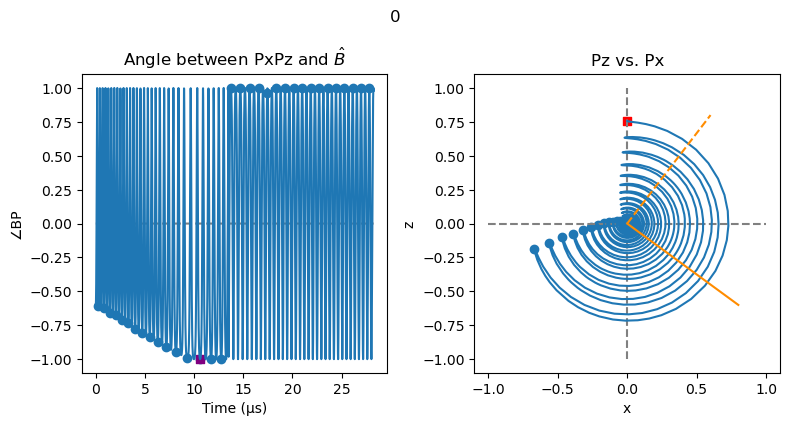

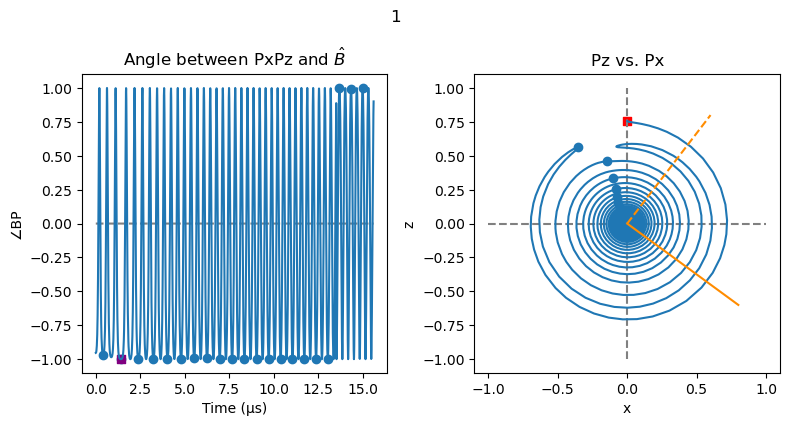

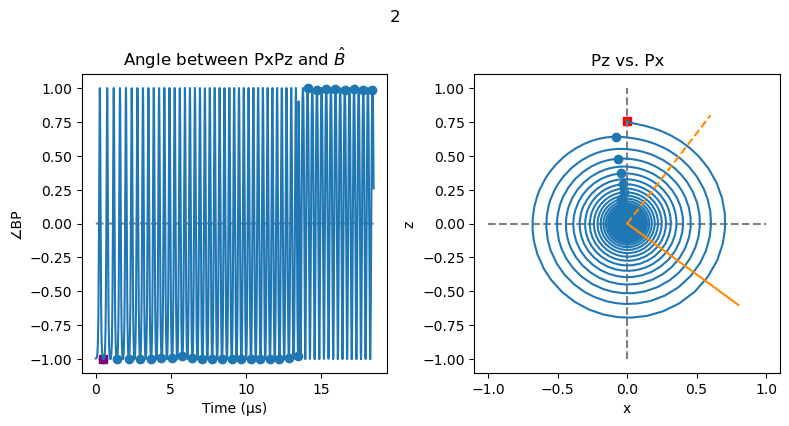

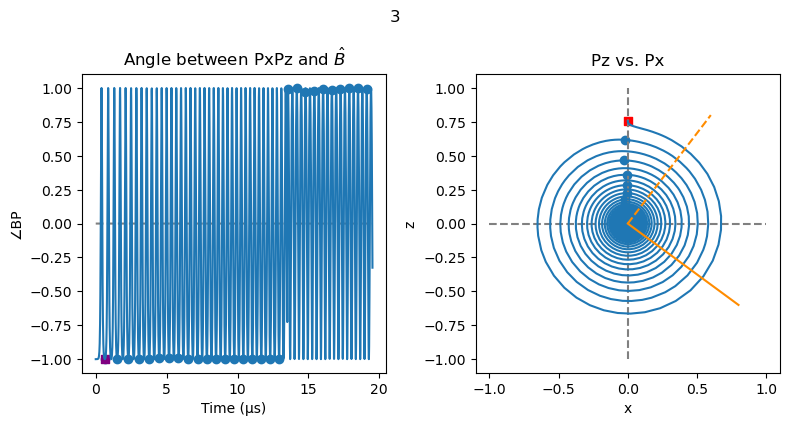

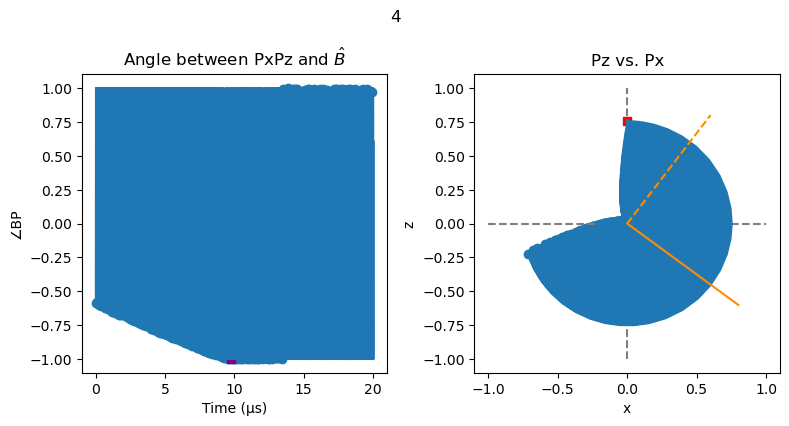

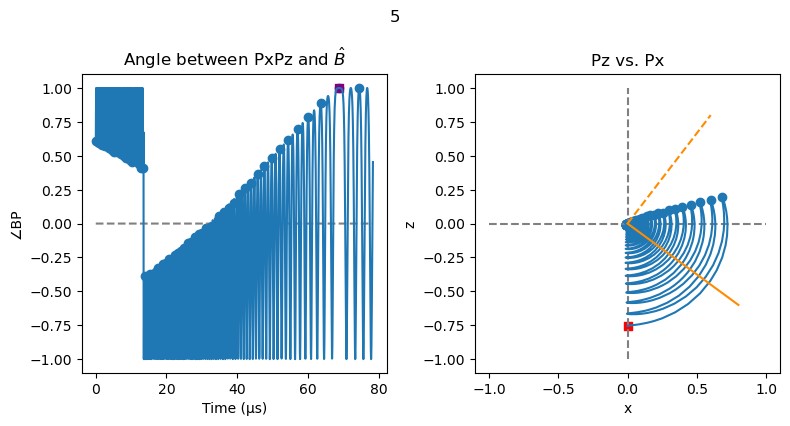

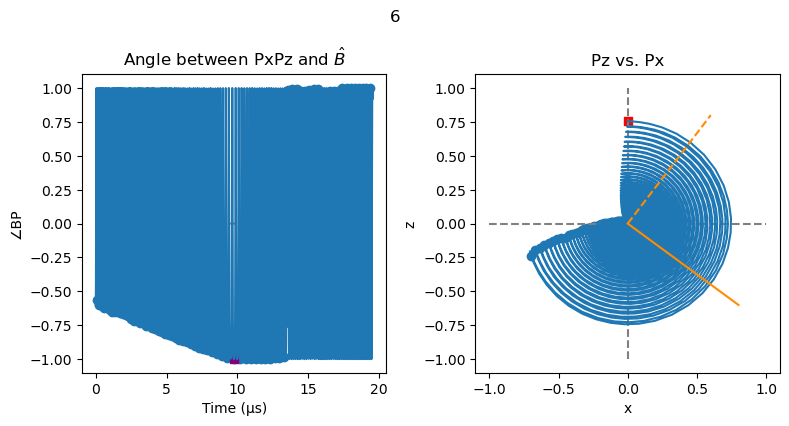

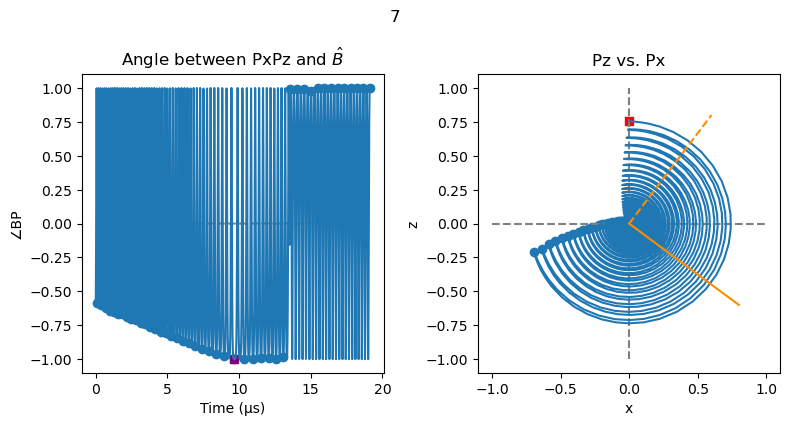

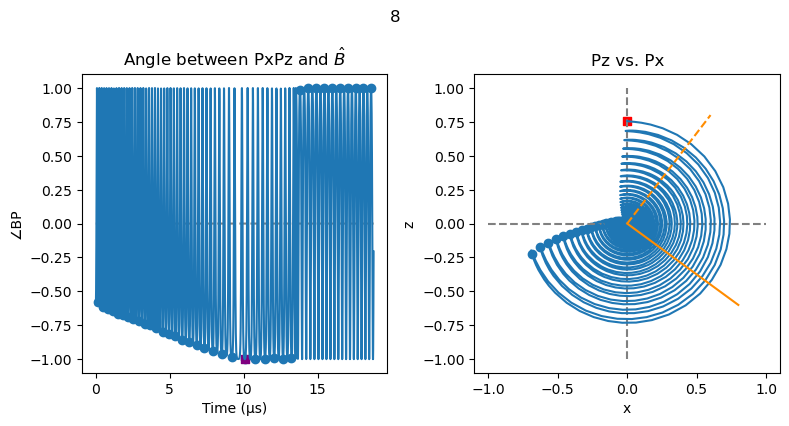

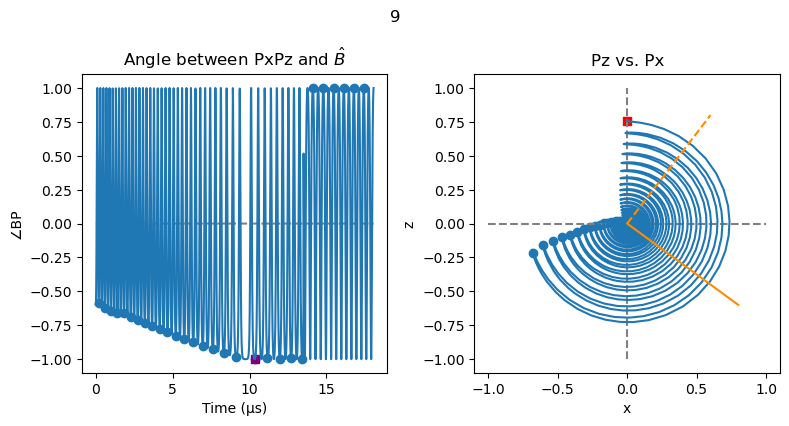

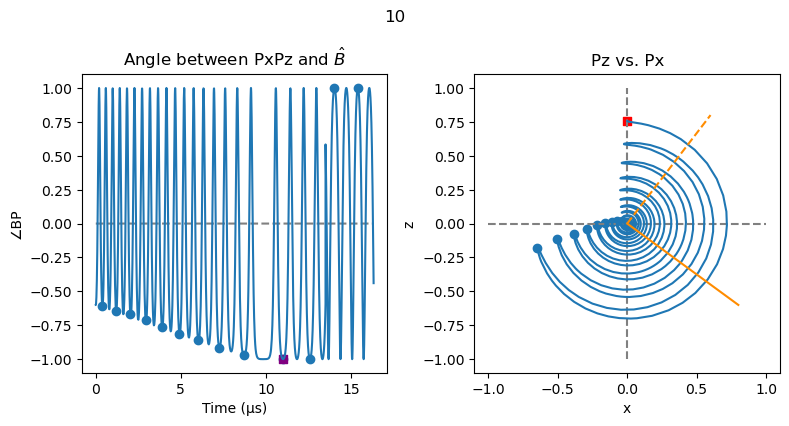

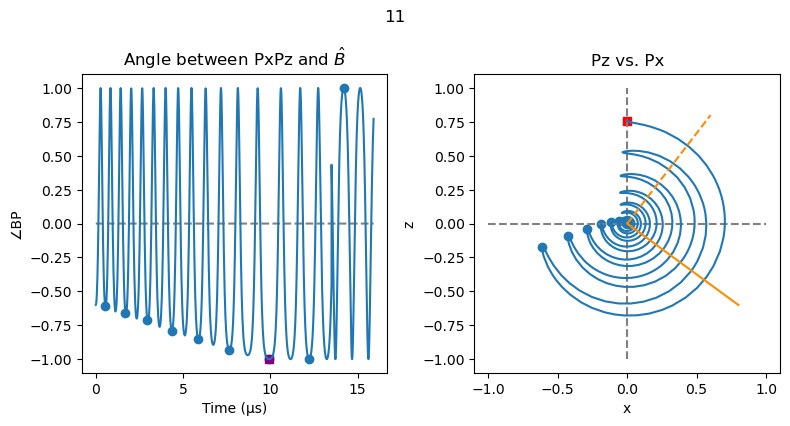

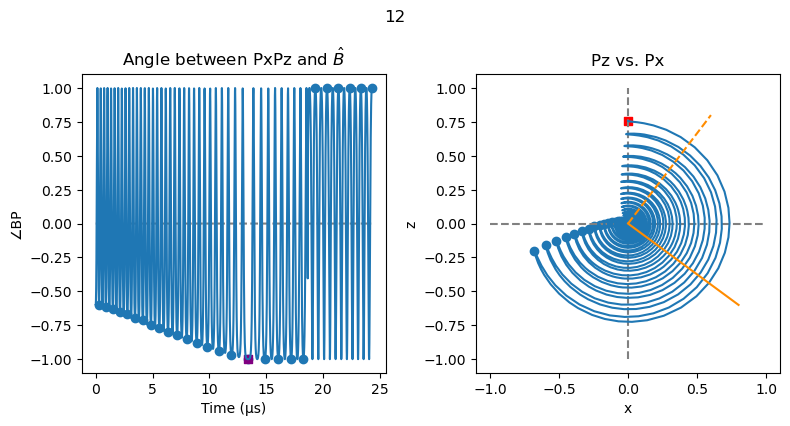

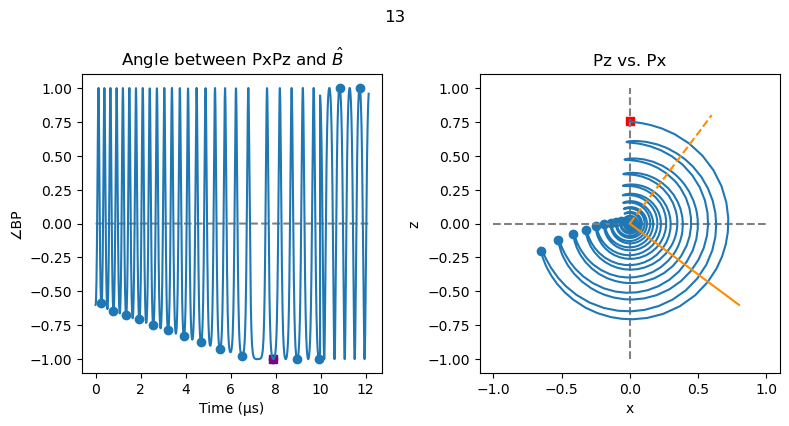

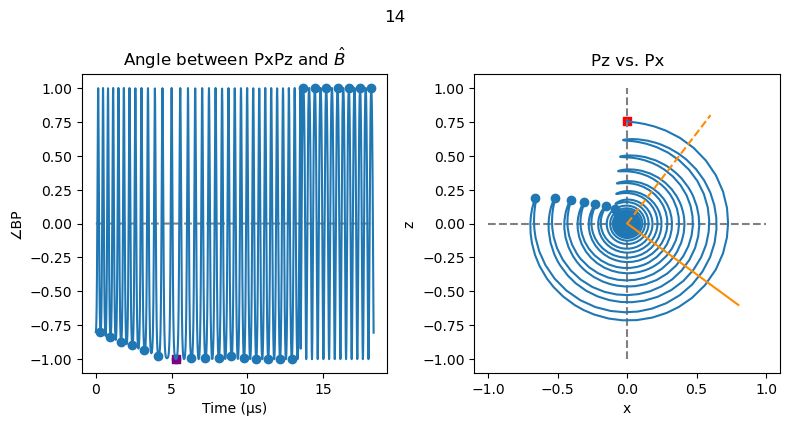

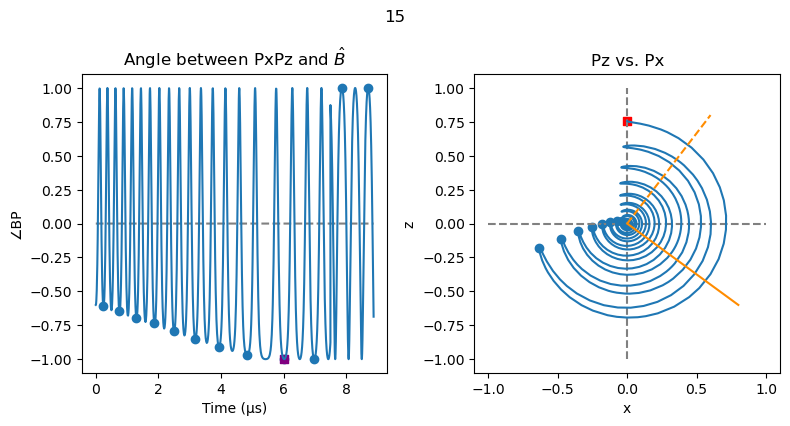

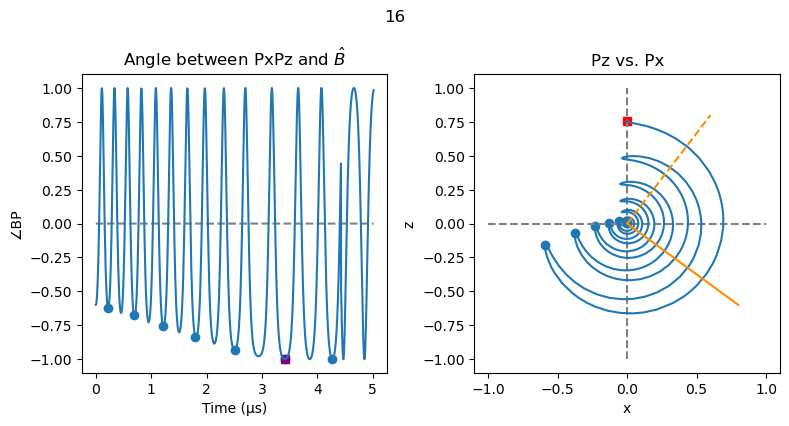

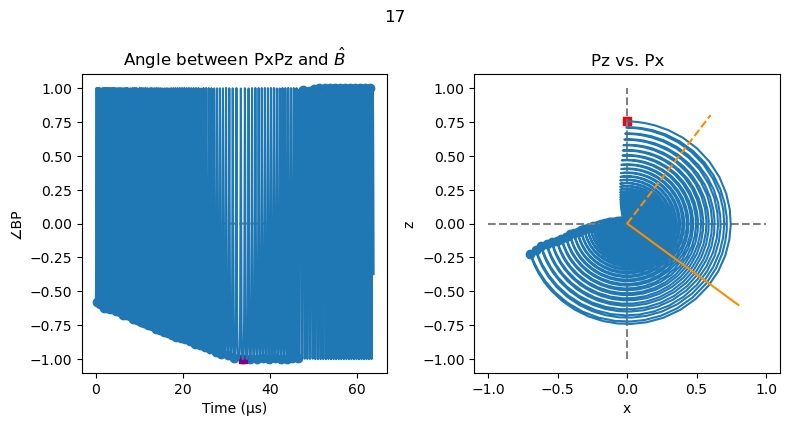

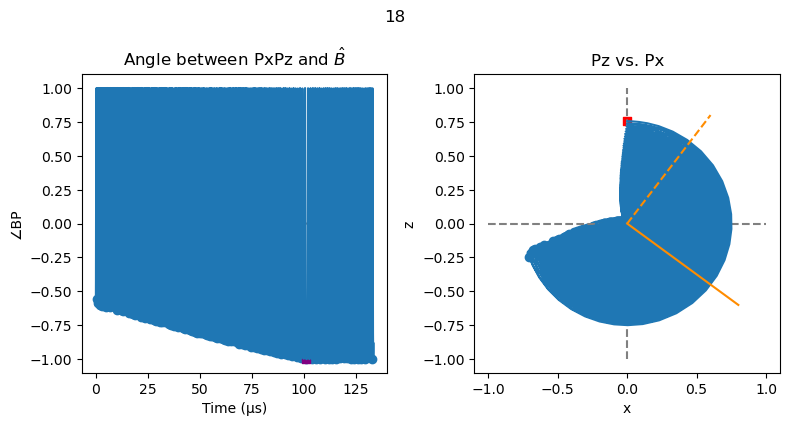

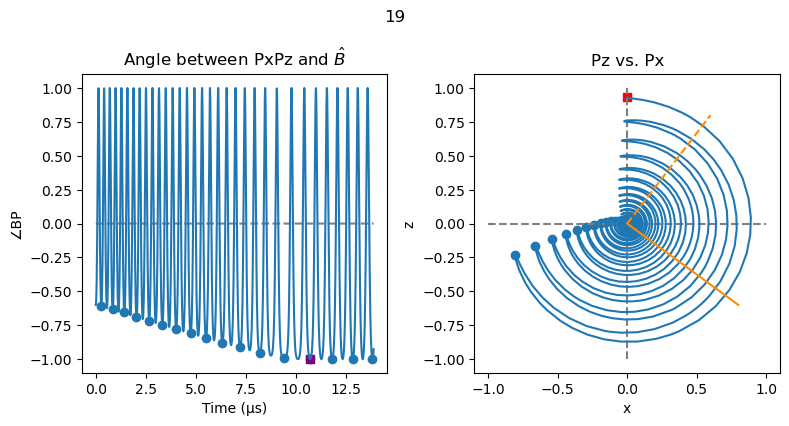

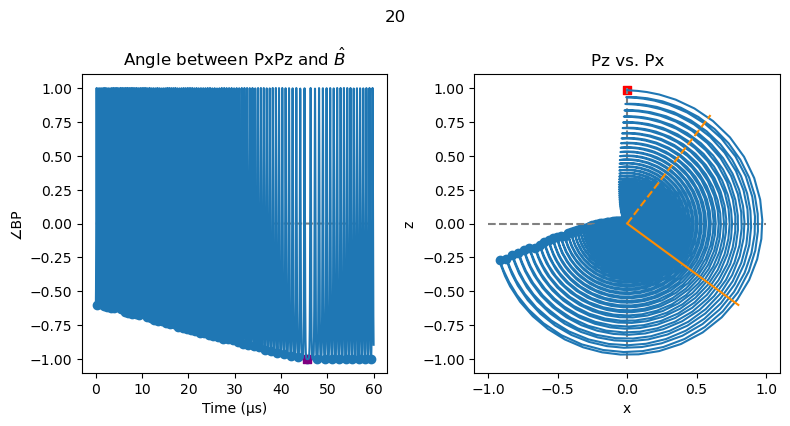

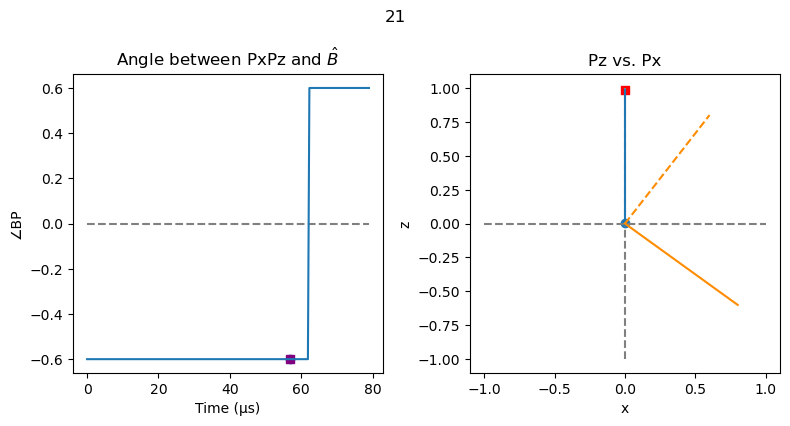

In [69]:
e_i=45
for i in range(len(datas)):
    plt.figure(figsize=(8.0,4.3))
#     fig.set_box_aspect(1) # fix later, make figures strict squares
    plt.subplot(1,2,1)
    plt.title('Angle between PxPz and $\hat{B}$')
    plt.plot(times[i],[0]*len(times[i]),'--',color='gray')
    plt.plot(times[i],Bs[i][:,e_i])
    plt.scatter(times[i][pts[i]],Bs[i][pts[i],e_i])
    plt.scatter(times[i][pts[i][switchs[i]]],Bs[i][pts[i][switchs[i]],e_i],marker='s',color='purple')
    # plt.xlim(10,17.5)
    plt.xlabel('Time (μs)')
    plt.ylabel('∠BP')
    
    plt.subplot(1,2,2)
    plt.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
    plt.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
    plt.title('Pz vs. Px')
    plt.plot(Pxs[i][:,e_i],Pzs[i][:,e_i])
    plt.scatter(Pxs[i][pts[i],e_i],Pzs[i][pts[i],e_i])
    plt.plot(B_lin*B[0],B_lin*B[2],label='B',color='darkorange')
    plt.plot(B_lin*-1*B[2],B_lin*B[0],'--',label='B⊥',color='darkorange')
    plt.scatter(Pxs[i][0,e_i],Pzs[i][0,e_i],color='red',marker='s')
    plt.xlabel('x')
    plt.ylabel('z')
#     plt.legend()
    
    plt.suptitle(i)
    plt.tight_layout()
    

Line of Best Fit: -0.0437235450197162 x+ -0.5940575664896388
Line of Best Fit: -0.044487151042767806 x+ -0.5880196418962347
Line of Best Fit: -0.001449860947816324 x+ 0.262489901585775
Line of Best Fit: -0.04450103429121696 x+ -0.5891367394343154
Line of Best Fit: -0.044244677688960704 x+ -0.591588284335134
Line of Best Fit: -0.044350637002886786 x+ -0.5908267709315519
Line of Best Fit: -0.04440796950953229 x+ -0.5909207131230861
Line of Best Fit: -0.04459565333296075 x+ -0.5872288922284697
Line of Best Fit: -0.04582743298872915 x+ -0.583091036111065
Line of Best Fit: -0.03275407585862433 x+ -0.5857415169518776
Line of Best Fit: -0.06084075447195604 x+ -0.5866262927650758
Line of Best Fit: -0.043961191409976674 x+ -0.7915493606211371
Line of Best Fit: -0.08026956719075998 x+ -0.5891718138773182
Line of Best Fit: -0.13673743910398226 x+ -0.5877799077446445
Line of Best Fit: -0.01295281883867586 x+ -0.5872971424962412
Line of Best Fit: -0.0042941619894297026 x+ -0.5843439394205997
Line o

/var/folders/8h/rzyrxjmn1gdfm_n6g9g16twc0000gs/T/ipykernel_10671/3604989849.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,3))


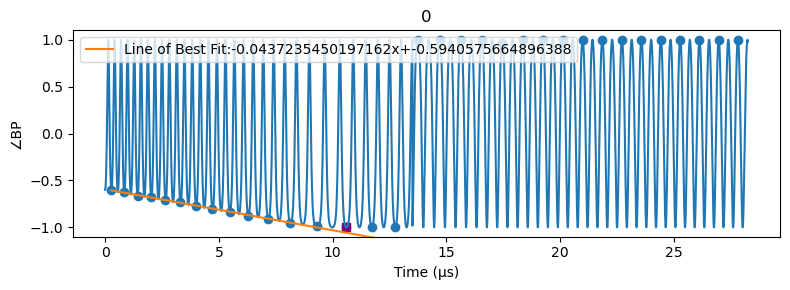

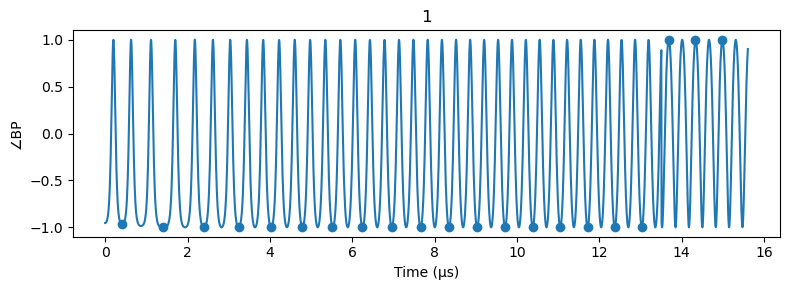

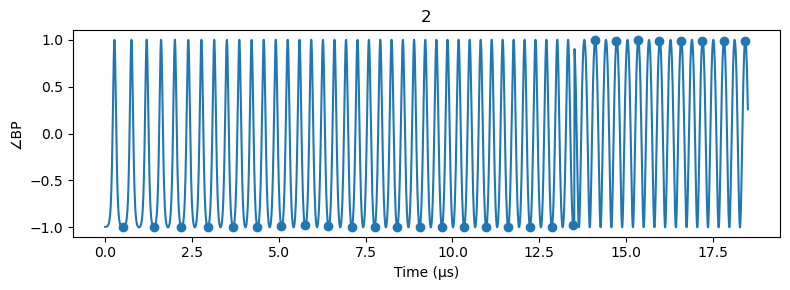

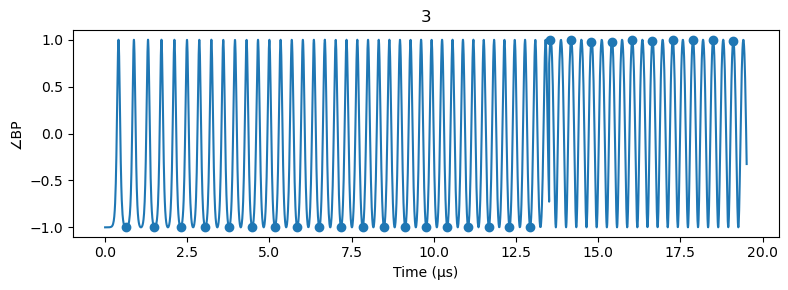

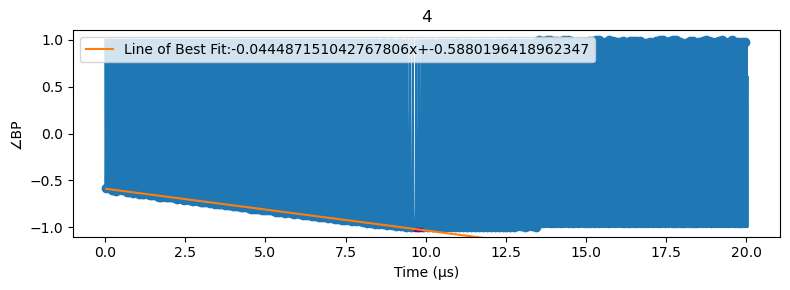

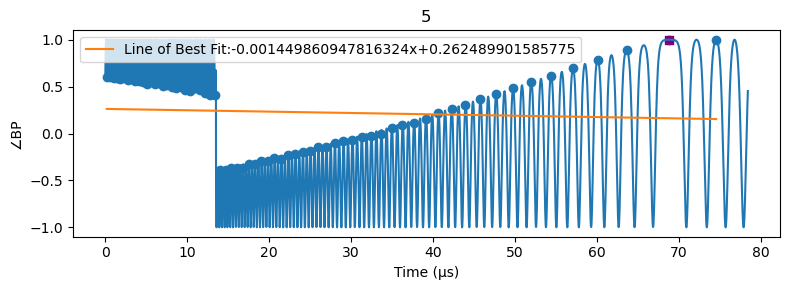

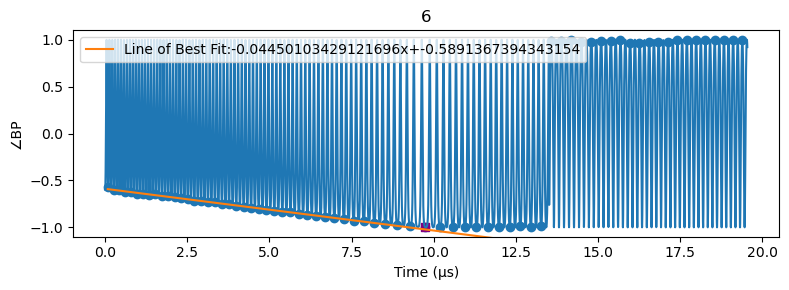

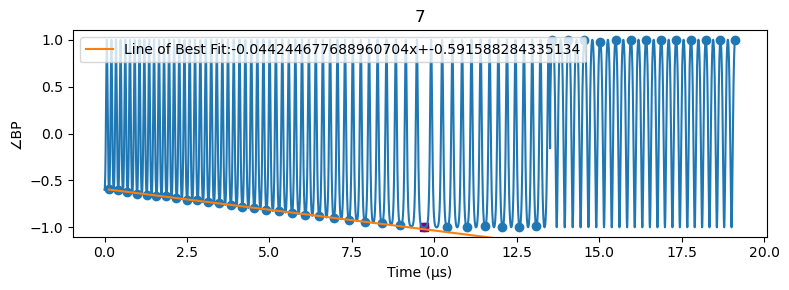

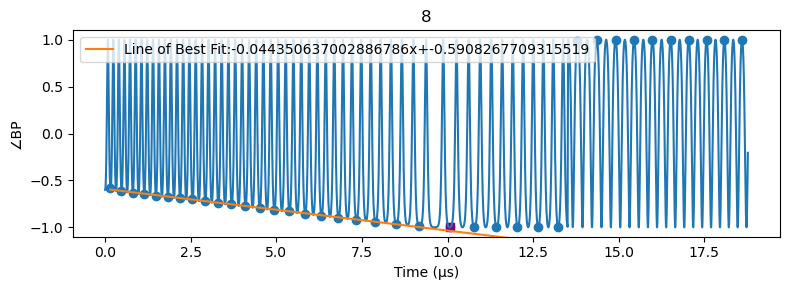

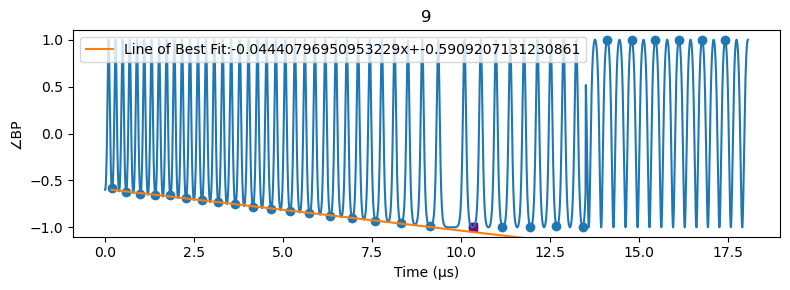

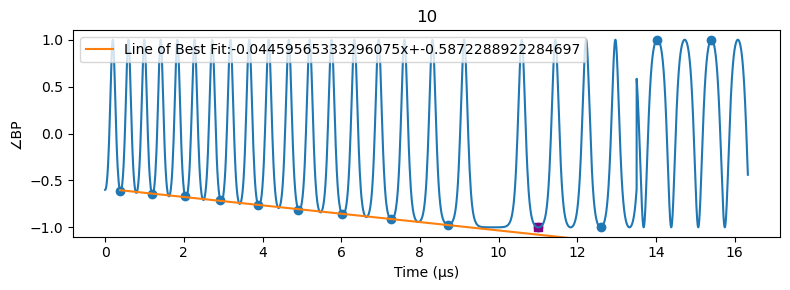

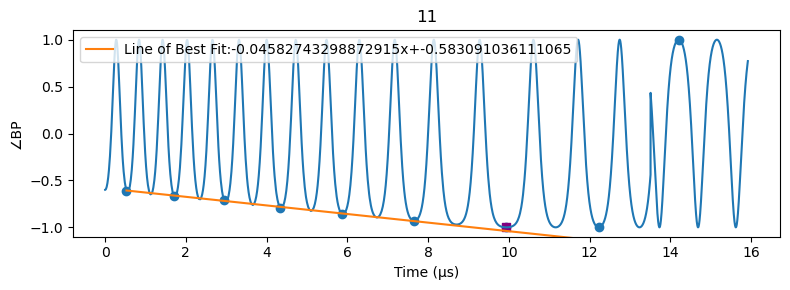

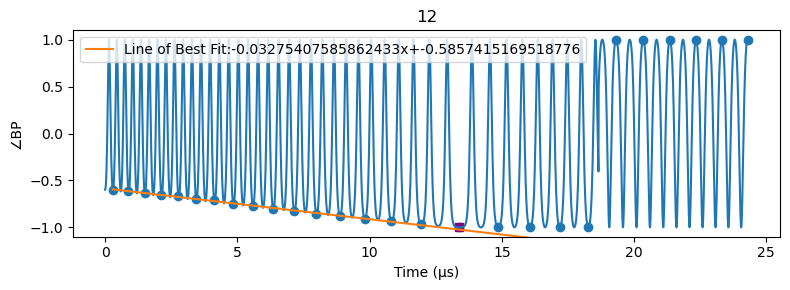

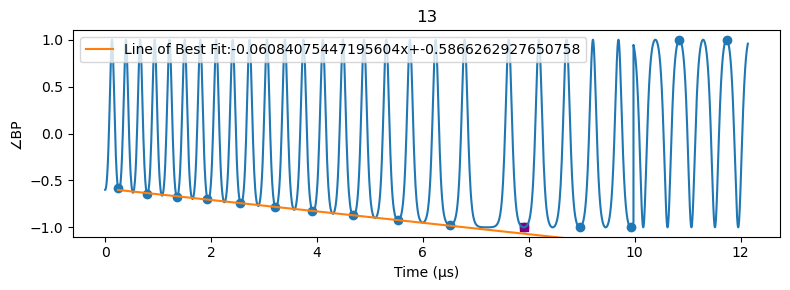

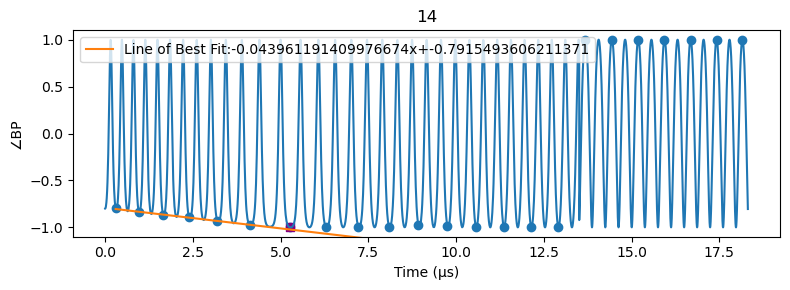

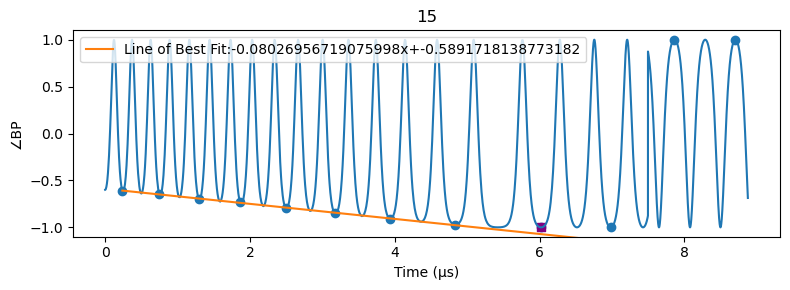

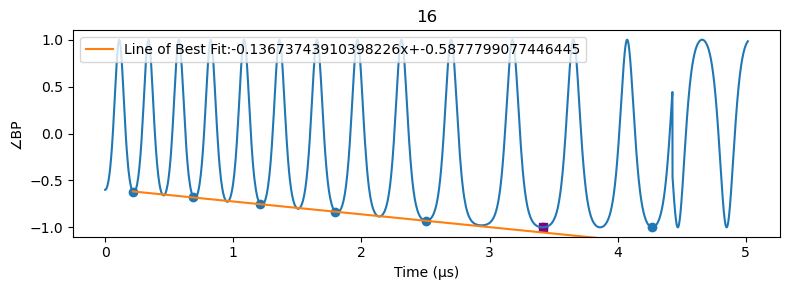

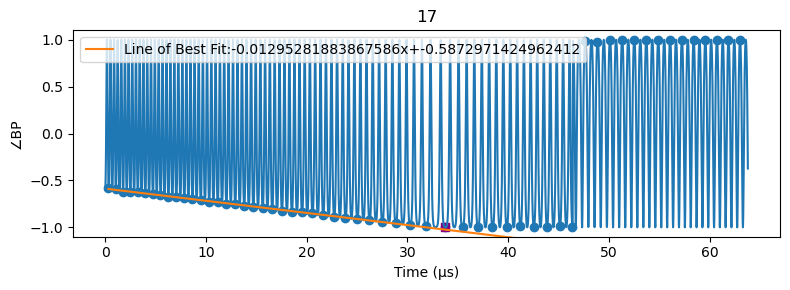

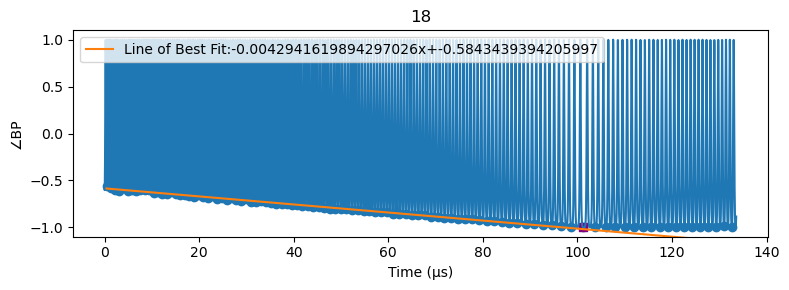

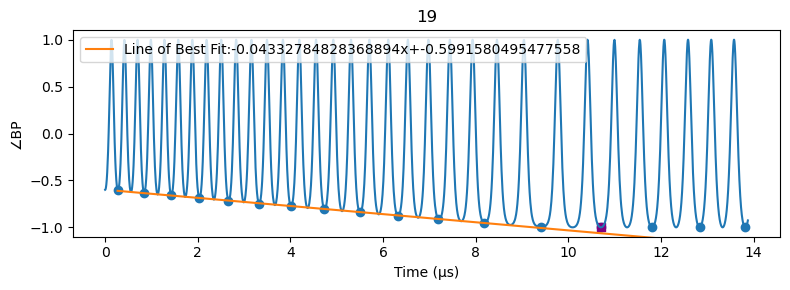

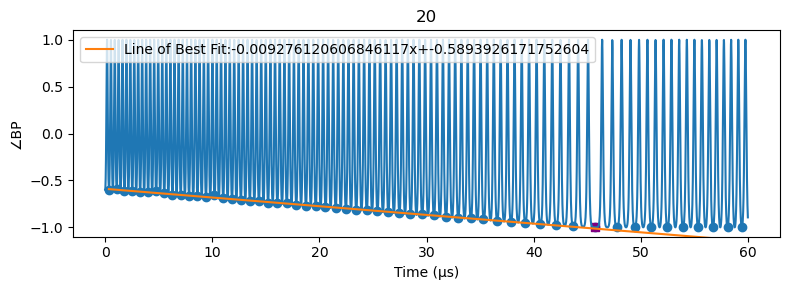

In [70]:
e_i=45
def model(x,m,b):
    return m*x+b
# def model(x,a,b,c):
#     return a*(x**2)+b*x+c

cycle=pts[:][1::2]
co=np.zeros((2,len(datas)))
for i in range(len(datas)-1):
    if switchs[i]>2:
        fit= curve_fit(model,times[i][pts[i][:switchs[i]]],Bs[i][pts[i][:switchs[i]],e_i])
        ans,cov=fit
        co[:,i]=ans
        print('Line of Best Fit:',ans[0],'x+',ans[1])
        y_data=model(times[i][pts[i]],ans[0],ans[1])
#         print('Line of Best Fit:',ans[0],'x^2+',ans[1],'x+',ans[2])
#         y_data=model(times[i][pts[i]],ans[0],ans[1],ans[2])


        plt.figure(figsize=(8,3))
        plt.title(i)
        plt.plot(times[i],Bs[i][:,e_i])
        plt.scatter(times[i][pts[i]],Bs[i][pts[i],e_i])
        plt.scatter(times[i][pts[i][switchs[i]]],Bs[i][pts[i][switchs[i]],e_i],marker='s',color='purple')
        plt.plot(times[i][pts[i]],y_data,label='Line of Best Fit:'+str(ans[0])+'x+'+str(ans[1]))
#         plt.plot(times[i][pts[i]],y_data,label='Line of Best Fit:'+str(ans[0])[:7]+'x^2+'+str(ans[1])[:7]+'x+'+str(ans[2])[:7])
        
    #     plt.xlim(-0.1,times[i][pts[i][1::2][switchs[i]+4]])
        plt.ylim(-1.1,1.1)
        plt.xlabel('Time (μs)')
        plt.ylabel('∠BP')
        plt.legend(loc=2)
        plt.tight_layout()
    else:
        plt.figure(figsize=(8,3))
        plt.title(i)
        plt.plot(times[i],Bs[i][:,e_i])
        plt.scatter(times[i][pts[i]],Bs[i][pts[i],e_i])
        plt.ylim(-1.1,1.1)
        plt.xlabel('Time (μs)')
        plt.ylabel('∠BP')
        plt.tight_layout()


Line of Best Fit: -0.0227239468882417 x+ 0.693990735779536


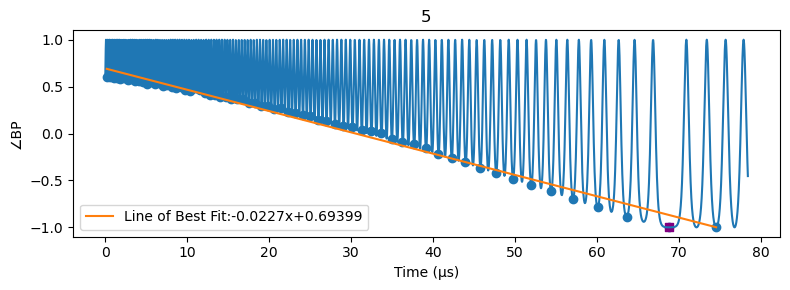

In [71]:
i=5
e_i=45
cut=-2
t_swap=1409
pts_swap=27
full45=np.append(Bs[i][:t_swap,e_i],-1*Bs[i][t_swap:,e_i])
pts45=np.append(Bs[i][pts[i][:pts_swap],e_i],-1*Bs[i][pts[i][pts_swap:],e_i])

fit= curve_fit(model,times[i][pts[i][:switchs[i]]],pts45[:switchs[i]])
ans,cov=fit
co[:,i]=ans
print('Line of Best Fit:',ans[0],'x+',ans[1])
y_data=model(times[i][pts[i]],ans[0],ans[1])

plt.figure(figsize=(8,3))
plt.title(i)
plt.plot(times[i],full45)
plt.scatter(times[i][pts[i]],pts45)
# plt.scatter(times[i][pts[i][pts_swap]],Bs[i][pts[i][pts_swap],e_i],color='red')
plt.plot(times[i][pts[i]],y_data,label='Line of Best Fit:'+str(ans[0])[:7]+'x+'+str(ans[1])[:7])
plt.scatter(times[i][pts[i][cut]],-1*Bs[i][pts[i][cut],e_i],color='purple',marker='s')
# plt.xlim(-0.1,times[i][pts[i][cut+5]])
plt.ylim(-1.1,1.1)
plt.xlabel('Time (μs)')
plt.ylabel('∠BP')
plt.legend(loc=3)
plt.tight_layout()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


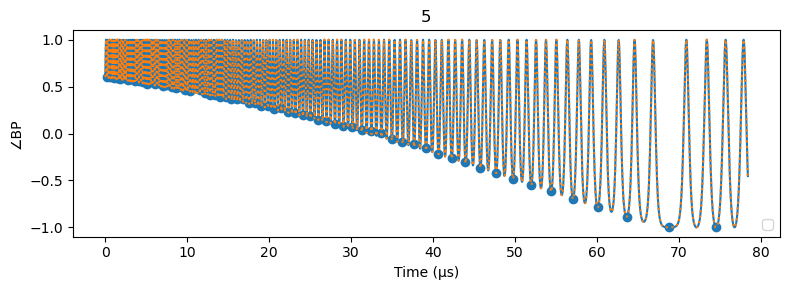

In [72]:
i=5
e_i=140

plt.figure(figsize=(8,3))
plt.title(i)
plt.plot(times[i],full45)
plt.scatter(times[i][pts[i]],pts45)
plt.plot(times[i],Bs[i][:,e_i],':')
# plt.scatter(times[i][pts[i]],pts45)
plt.ylim(-1.1,1.1)
plt.xlabel('Time (μs)')
plt.ylabel('∠BP')
plt.legend(loc=4)
plt.tight_layout()

Line of Best Fit: 4.99138746636578 x+ -20.40756021996174
Line of Best Fit: -5.22671974692591 x+ 20.278149472349657


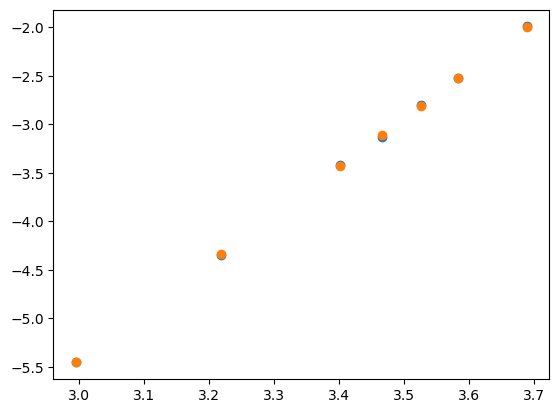

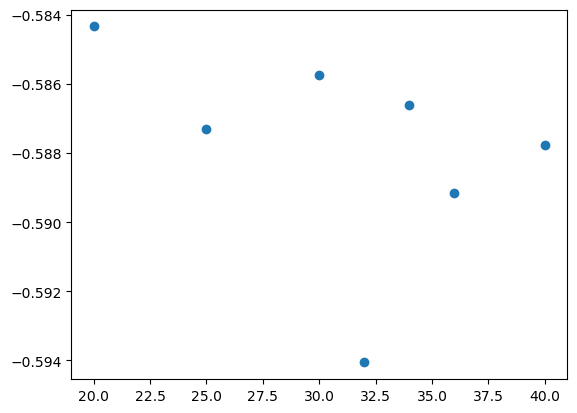

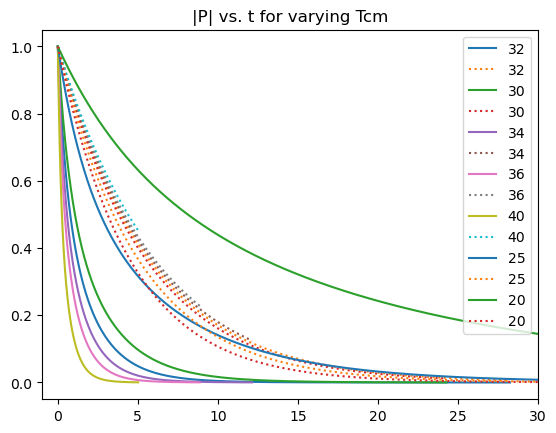

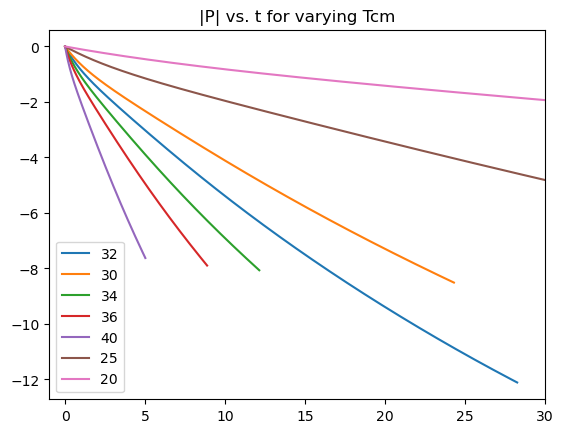

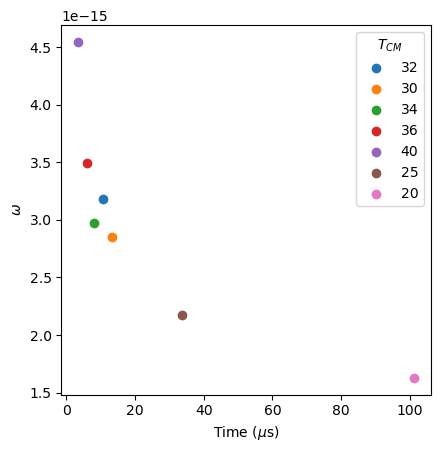

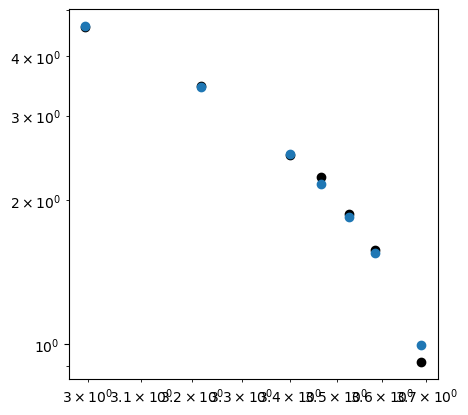

In [81]:
plt.figure(figsize=(5,4))
plt.scatter(Tcms,np.abs(co[0,Tcm_ind]))
plt.title('a vs. $T_{CM}$')
plt.xlabel('$T_{CM}$')
plt.ylabel('a')

plt.figure(figsize=(5,4))
plt.scatter(Tcms,np.abs(co[1,Tcm_ind]))
plt.title('b vs. $T_{CM}$')
plt.xlabel('$T_{CM}$')
plt.ylabel('b')


fit= curve_fit(model,np.log(Tcms),np.log(np.abs(co[0,Tcm_ind])))
ans,cov=fit
print('Line of Best Fit:',ans[0],'x+',ans[1])
y_data=model(np.log(Tcms),ans[0],ans[1])
plt.figure()
plt.scatter(np.log(Tcms),np.log(np.abs(co[0,Tcm_ind])))
plt.scatter(np.log(Tcms),y_data)

plt.figure()
plt.scatter(Tcms,co[1,Tcm_ind])

plt.figure()
plt.title('|P| vs. t for varying Tcm')
plt.xlim(-1,30)
for i in range(len(Tcm_ind)):
    plt.plot(times[Tcm_ind[i]],radii[Tcm_ind[i]][:,e_i],label=Tcms[i])
    plt.plot(times[Tcm_ind[i]],np.exp(times[Tcm_ind[i]]*-1*(Tcms[i]**-0.5)),':',label=Tcms[i])
plt.legend()
plt.figure()
plt.title('|P| vs. t for varying Tcm')
plt.xlim(-1,30)
P_Tcm_co=np.zeros((2,len(Tcm_ind)))
for i in range(len(Tcm_ind)):
    plt.plot(times[Tcm_ind[i]],np.log(radii[Tcm_ind[i]][:,e_i]),label=Tcms[i])
#     fit= curve_fit(model,times[Tcm_ind[i]],np.log(radii[Tcm_ind[i]][:,e_i]))
#     ans,cov=fit
#     print('Line of Best Fit:',ans[0],'x+',ans[1],' for Tcm=',Tcms[i])
#     y_data=model(times[Tcm_ind[i]],ans[0],ans[1])
#     P_Tcm_co[:,i]=ans
# #     plt.plot(times[Tcm_ind[i]],y_data,color='black')    
plt.legend()
# plt.figure()
# plt.scatter(np.log(Tcms),np.log(np.abs(P_Tcm_co[0])))
# fit= curve_fit(model,np.log(Tcms),np.log(np.abs(P_Tcm_co[0])))
# ans,cov=fit
# print('Line of Best Fit slopes:',ans[0],'x+',ans[1])
# y_data=model(np.log(Tcms),ans[0],ans[1])
# plt.scatter(np.log(Tcms),y_data)


fig,ax=plt.subplots()
ax.set_box_aspect(1)
for i in range(len(Tcm_ind)):
#     ax.plot(times[Tcm_ind[i]][pts[Tcm_ind[i]][1:]],afs[Tcm_ind[i]],label=Tcms[i])
    ax.scatter(times[Tcm_ind[i]][pts[Tcm_ind[i]][switchs[Tcm_ind[i]]]],afs[Tcm_ind[i]][switchs[Tcm_ind[i]]-1],label=Tcms[i])
#     ax.scatter(Tcms[i],afs[Tcm_ind[i]][switchs[Tcm_ind[i]]],label=Tcms[i],color='red')
ax.legend(title='$T_{CM}$')
ax.set_xlabel('Time ($\mu$s)')
ax.set_ylabel('$\omega$')

fig,ax=plt.subplots()
ax.set_box_aspect(1)
force_set=np.array(())
for i in range(len(Tcm_ind)):
    ax.scatter(np.log(Tcms[i]),np.log(times[Tcm_ind[i]][pts[Tcm_ind[i]][switchs[Tcm_ind[i]]-1]]),label=Tcms[i],color='black')
    force_set=np.append(force_set,times[Tcm_ind[i]][pts[Tcm_ind[i]][switchs[Tcm_ind[i]]-1]])
fit= curve_fit(model,np.log(Tcms),np.log(force_set))
ans,cov=fit
print('Line of Best Fit:',ans[0],'x+',ans[1])
y_data=model(np.log(Tcms),ans[0],ans[1])
ax.scatter(np.log(Tcms),y_data)
# ax.legend()
# ax.set_xlabel('Time ($\mu$s)')
# ax.set_ylabel('$\omega$')
plt.xscale('log')
plt.yscale('log')


# for i in Tcm_ind:
#     y_data=model(times[i][pts[i]],co[0,i],co[1,i])
    
    
#     plt.figure(figsize=(8.0,4.3))
# #     fig.set_box_aspect(1) # fix later, make figures strict squares
#     plt.subplot(1,2,1)
#     plt.title('Angle between PxPz and B')
#     plt.plot(times[i],[0]*len(times[i]),'--',color='gray')
#     plt.plot(times[i],Bs[i][:,e_i])
#     plt.scatter(times[i][pts[i]],Bs[i][pts[i],e_i],color='orange')
#     plt.scatter(times[i][pts[i][switchs[i]]],Bs[i][pts[i][switchs[i]],e_i],marker='s',color='purple')
#     # plt.xlim(10,17.5)
#     plt.plot(times[i][pts[i]],y_data,label='Line of Best Fit:'+str(co[0,i])[:7]+'x+'+str(co[1,i])[:7])
#     plt.xlabel('Time (μs)')
#     plt.ylabel('∠BP')
#     plt.ylim(-1.1,1.1)
#     plt.legend(loc=2)
    
#     plt.subplot(1,2,2)
#     plt.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
#     plt.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
#     plt.title('Pz vs. Px')
#     plt.plot(Pxs[i][:,e_i],Pzs[i][:,e_i])
# #     plt.scatter(Px[cycle,e],Pz[cycle,e])
#     plt.plot(B_lin*B[0],B_lin*B[2],label='B',color='darkorange')
#     plt.plot(B_lin*-1*B[2],B_lin*B[0],'--',label='B⊥',color='darkorange')
#     plt.scatter(Pxs[i][0,e_i],Pzs[i][0,e_i],color='red',marker='s')
#     plt.xlabel('x')
#     plt.ylabel('z')

    
#     plt.suptitle('Tcm='+str(datas[i]['Tcm']))
#     plt.tight_layout()
    

Line of Best Fit: 0.4515692285991849 x+ -14.748628093514897


Text(0, 0.5, '$\\omega$')

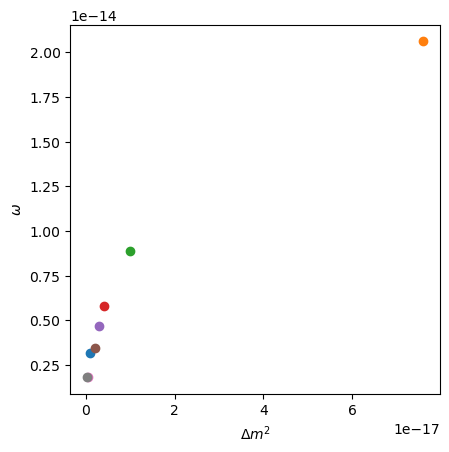

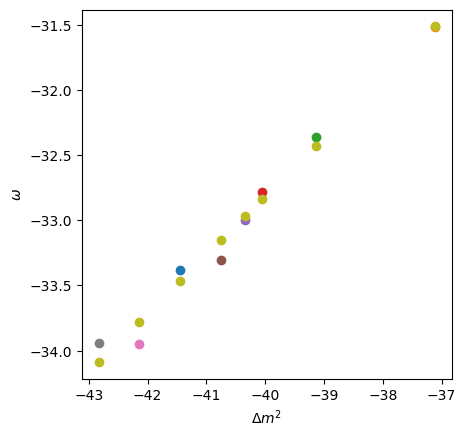

In [14]:
# plt.figure(figsize=(5,4))
# plt.scatter(Dm2s,co[0,Dm2_ind])
# plt.title('a vs. $\Delta m^2$')
# plt.xlabel('$\Delta m^2$')
# plt.ylabel('a')

# plt.figure(figsize=(5,4))
# plt.scatter(Dm2s,co[1,Dm2_ind])
# plt.title('b vs. $\Delta m^2$')
# plt.xlabel('$\Delta m^2$')
# plt.ylabel('b')



# plt.figure()
# plt.title('|P| vs. t for varying Dm2')
# # plt.xlim(-1,30)
# for i in range(len(Dm2_ind)):
#     plt.plot(times[Dm2_ind[i]],radii[Dm2_ind[i]][:,e_i],label=Dm2s[i])
# plt.legend()

fig,ax=plt.subplots()
ax.set_box_aspect(1)
for i in range(len(Dm2_ind)):
#     ax.plot(times[Dm2_ind[i]][pts[Dm2_ind[i]][1:]],afs[Dm2_ind[i]],label=Dm2_ind[i])
#     ax.scatter(times[Dm2_ind[i]][pts[Dm2_ind[i]][switchs[Dm2_ind[i]]]],afs[Dm2_ind[i]][switchs[Dm2_ind[i]]-1],label=Dm2s[i])
    ax.scatter(Dm2s[i],afs[Dm2_ind[i]][switchs[Dm2_ind[i]]-1])
# ax.legend()
ax.set_xlabel('$\Delta m^2$')
ax.set_ylabel('$\omega$')

fig,ax=plt.subplots()
ax.set_box_aspect(1)
force_set=np.array(())
for i in range(len(Dm2_ind)):
#     ax.plot(times[Dm2_ind[i]][pts[Dm2_ind[i]][1:]],afs[Dm2_ind[i]],label=Dm2_ind[i])
#     ax.scatter(times[Dm2_ind[i]][pts[Dm2_ind[i]][switchs[Dm2_ind[i]]]],afs[Dm2_ind[i]][switchs[Dm2_ind[i]]],label=Dm2s[i])
    ax.scatter(np.log(Dm2s[i]),np.log(afs[Dm2_ind[i]][switchs[Dm2_ind[i]]-1]),label=Dm2s[i])
    force_set=np.append(force_set,afs[Dm2_ind[i]][switchs[Dm2_ind[i]]-1])
fit= curve_fit(model,np.log(Dm2s),np.log(force_set))
ans,cov=fit
print('Line of Best Fit:',ans[0],'x+',ans[1])
y_data=model(np.log(Dm2s),ans[0],ans[1])
ax.scatter(np.log(Dm2s),y_data)
# ax.legend()
ax.set_xlabel('$\Delta m^2$')
ax.set_ylabel('$\omega$')
# plt.xscale('log')
# plt.yscale('log')

# for i in range(len(Dm2_ind)):
#     dm=Dm2_ind[i]
#     y_data=model(times[dm][pts[dm]],co[0,dm],co[1,dm])
    
    
#     plt.figure(figsize=(8.0,4.3))
# #     fig.set_box_aspect(1) # fix later, make figures strict squares
#     plt.subplot(1,2,1)
#     plt.title('Angle between PxPz and B')
#     plt.plot(times[dm],[0]*len(times[dm]),'--',color='gray')
#     plt.plot(times[dm],Bs[dm][:,e_i])
#     plt.scatter(times[dm][pts[dm]],Bs[dm][pts[dm],e_i],color='orange')
#     plt.scatter(times[dm][pts[dm][switchs[dm]]],Bs[dm][pts[dm][switchs[dm]],e_i],marker='s',color='purple')
#     # plt.xlim(10,17.5)
#     plt.plot(times[dm][pts[dm]],y_data,label='Line of Best Fit:'+str(co[0,dm])[:7]+'x'+str(co[1,dm])[:7])
#     plt.xlabel('Time (μs)')
#     plt.ylabel('∠BP')
#     plt.legend()
    
#     plt.subplot(1,2,2)
#     plt.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
#     plt.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
#     plt.title('Pz vs. Px')
#     plt.plot(Pxs[dm][:,e_i],Pzs[dm][:,e_i])
# #     plt.scatter(Px[cycle,e],Pz[cycle,e])
#     plt.plot(B_lin*B[0],B_lin*B[2],label='B',color='darkorange')
#     plt.plot(B_lin*-1*B[2],B_lin*B[0],'--',label='B⊥',color='darkorange')
#     plt.scatter(Pxs[dm][0,e_i],Pzs[dm][0,e_i],color='red',marker='s')
#     plt.xlabel('x')
#     plt.ylabel('z')

    
#     plt.suptitle('Dm2='+str(Dm2s[i]))
#     plt.tight_layout()
    

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Line of Best Fit: 12.272184628982885 x+ -0.7595459957168018


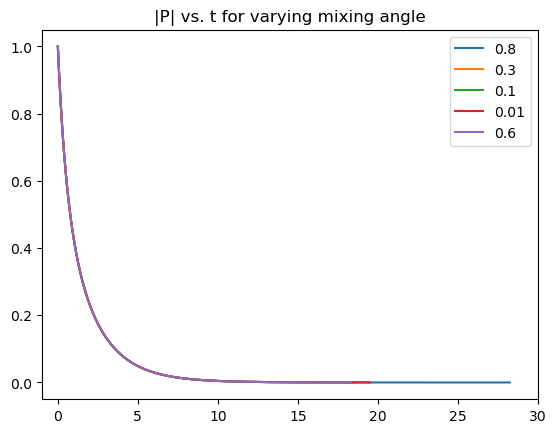

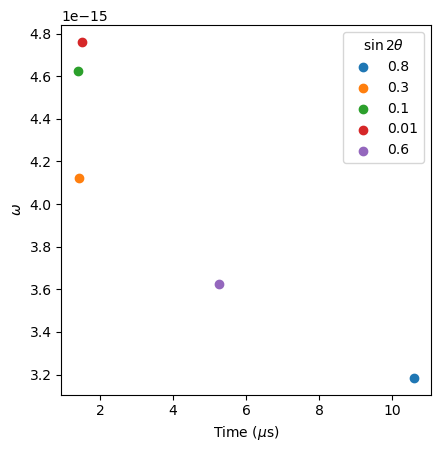

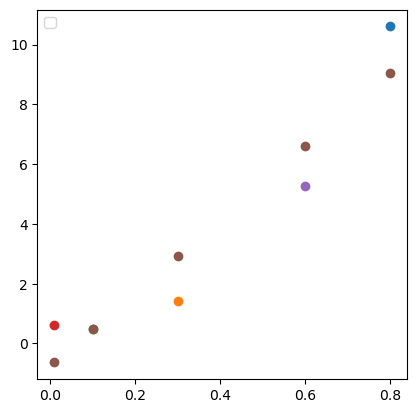

In [15]:
plt.figure()
plt.title('|P| vs. t for varying mixing angle')
plt.xlim(-1,30)
for i in range(len(mix_ind)):
    plt.plot(times[mix_ind[i]],radii[mix_ind[i]][:,e_i],label=mixs[i])
plt.legend()

fig,ax=plt.subplots()
ax.set_box_aspect(1)
for i in range(len(mix_ind)):
#     ax.plot(times[mix_ind[i]][pts[mix_ind[i]][1:]],afs[mix_ind[i]],label=mixs[i])
    if switchs[mix_ind[i]]>0:
        ax.scatter(times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]],afs[mix_ind[i]][switchs[mix_ind[i]]-1],label=mixs[i])
    else:
        ax.scatter(times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]+1]],afs[mix_ind[i]][switchs[mix_ind[i]]],label=mixs[i])
ax.legend(title=r'$\sin2\theta$')
ax.set_xlabel('Time ($\mu$s)')
ax.set_ylabel('$\omega$')

fig,ax=plt.subplots()
ax.set_box_aspect(1)
force_set=np.array(())
time_set=np.array(())
for i in range(len(mix_ind)):
#     ax.plot(times[mix_ind[i]][pts[mix_ind[i]][1:]],afs[mix_ind[i]],label=mixs[i])
    if switchs[mix_ind[i]]>0:
#         ax.scatter(np.log(times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]]),np.log(afs[mix_ind[i]][switchs[mix_ind[i]]-1]),label=mixs[i])
        force_set=np.append(force_set,afs[mix_ind[i]][switchs[mix_ind[i]]-1])
    else:
#         ax.scatter(np.log(times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]]),np.log(afs[mix_ind[i]][switchs[mix_ind[i]]]),label=mixs[i])
        force_set=np.append(force_set,afs[mix_ind[i]][switchs[mix_ind[i]]+1])
    ax.scatter(mixs[i],times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]])
    time_set=np.append(time_set,times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]])
fit= curve_fit(model,mixs,time_set)
ans,cov=fit
print('Line of Best Fit:',ans[0],'x+',ans[1])
y_data=model(mixs,ans[0],ans[1])
ax.scatter(mixs,y_data)
ax.legend()
# ax.set_xlabel('Time ($\mu$s)')
# ax.set_ylabel('$\omega$')
# plt.xscale('log')
# plt.yscale('log')

# for i in range(len(mix_ind)):
#     mx=mix_ind[i]
#     cos=np.sqrt(1-(mixs[i]**2))
# #     B=np.array([mixs[i],0,-1*cos])
#     y_data=model(times[mx][pts[mx]],co[0,mx],co[1,mx])
    
    
#     plt.figure(figsize=(8.0,4.3))
# #     fig.set_box_aspect(1) # fix later, make figures strict squares
#     plt.subplot(1,2,1)
#     plt.title('Angle between PxPz and B')
#     plt.plot(times[mx],[0]*len(times[mx]),'--',color='gray')
#     plt.plot(times[mx],Bs[mx][:,e_i])
#     plt.scatter(times[mx][pts[mx]],Bs[mx][pts[mx],e_i],color='orange')
#     plt.scatter(times[mx][pts[mx][switchs[mx]]],Bs[mx][pts[mx][switchs[mx]],e_i],marker='s',color='purple')
#     # plt.xlim(10,17.5)
#     plt.plot(times[mx][pts[mx]],y_data,label='Line of Best Fit:'+str(co[0,mx])[:7]+'x+'+str(co[1,mx])[:7])
#     plt.xlabel('Time (μs)')
#     plt.ylabel('∠BP')
#     plt.ylim(-1.1,1.1)
#     plt.legend(loc=2)
    
#     plt.subplot(1,2,2)
#     plt.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
#     plt.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
#     plt.title('Pz vs. Px')
#     plt.plot(Pxs[mx][:,e_i],Pzs[mx][:,e_i])
# #     plt.scatter(Px[cycle,e],Pz[cycle,e])
#     plt.plot(B_lin*mixs[i],B_lin*-1*cos,label='B',color='darkorange')
#     plt.plot(B_lin*cos,B_lin*mixs[i],'--',label='B⊥',color='darkorange')
#     plt.scatter(Pxs[mx][pts[mx],e_i],Pzs[mx][pts[mx],e_i],color='orange')
#     plt.scatter(Pxs[mx][0,e_i],Pzs[mx][0,e_i],color='red',marker='s')
#     plt.xlabel('x')
#     plt.ylabel('z')

    
#     plt.suptitle('$\phi$='+str(mixs[i]))
#     plt.tight_layout()
    

Line of Best Fit: 3.421921249669287 x+ -0.7164852275270784


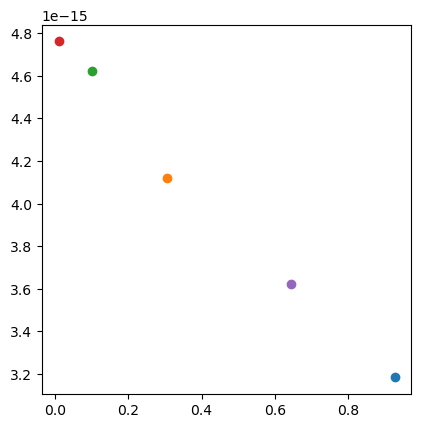

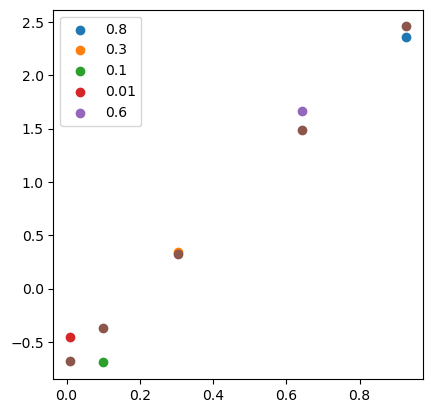

In [16]:
fig,ax=plt.subplots()
ax.set_box_aspect(1)
# force_set=np.array(())
# time_set=np.array(())
for i in range(len(mix_ind)):
#     ax.plot(times[mix_ind[i]][pts[mix_ind[i]][1:]],afs[mix_ind[i]],label=mixs[i])
    if switchs[mix_ind[i]]>0:
        ax.scatter(np.arcsin(mixs[i]),afs[mix_ind[i]][switchs[mix_ind[i]]-1],label=mixs[i])
#         force_set=np.append(force_set,afs[mix_ind[i]][switchs[mix_ind[i]]-1])
    else:
        ax.scatter(np.arcsin(mixs[i]),afs[mix_ind[i]][switchs[mix_ind[i]]],label=mixs[i])
#         force_set=np.append(force_set,afs[mix_ind[i]][switchs[mix_ind[i]]])
#     time_set=np.append(time_set,times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]])
#     ax.scatter(np.arcsin(mixs[i]),times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]],label=mixs[i])

fig,ax=plt.subplots()
ax.set_box_aspect(1)
# force_set=np.array(())
time_set=np.array(())
for i in range(len(mix_ind)):
#     ax.plot(times[mix_ind[i]][pts[mix_ind[i]][1:]],afs[mix_ind[i]],label=mixs[i])
    if switchs[mix_ind[i]]>0:
        ax.scatter(np.arcsin(mixs[i]),np.log(times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]]),label=mixs[i])
#         force_set=np.append(force_set,afs[mix_ind[i]][switchs[mix_ind[i]]-1])
    else:
        ax.scatter(np.arcsin(mixs[i]),np.log(times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]]),label=mixs[i])
#         force_set=np.append(force_set,afs[mix_ind[i]][switchs[mix_ind[i]]])
    time_set=np.append(time_set,times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]])
#     ax.scatter(np.arcsin(mixs[i]),times[mix_ind[i]][pts[mix_ind[i]][switchs[mix_ind[i]]]],label=mixs[i])
fit= curve_fit(model,np.arcsin(mixs),np.log(time_set))
ans,cov=fit
print('Line of Best Fit:',ans[0],'x+',ans[1])
y_data=model(np.arcsin(mixs),ans[0],ans[1])
ax.scatter(np.arcsin(mixs),y_data)
ax.legend()

(0.0, 13.87705516569129)

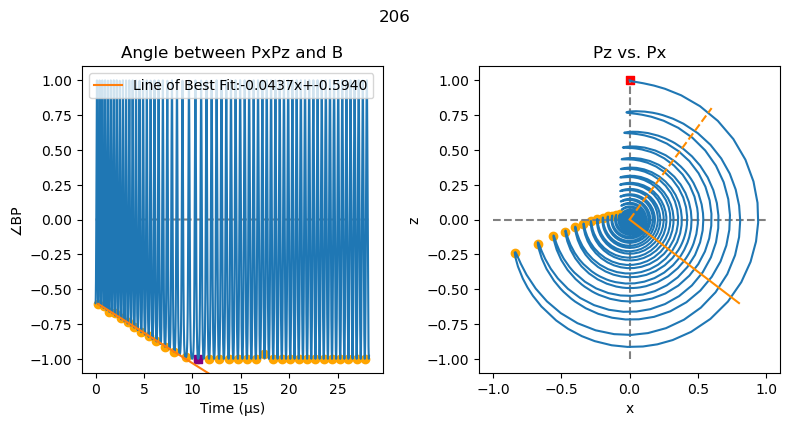

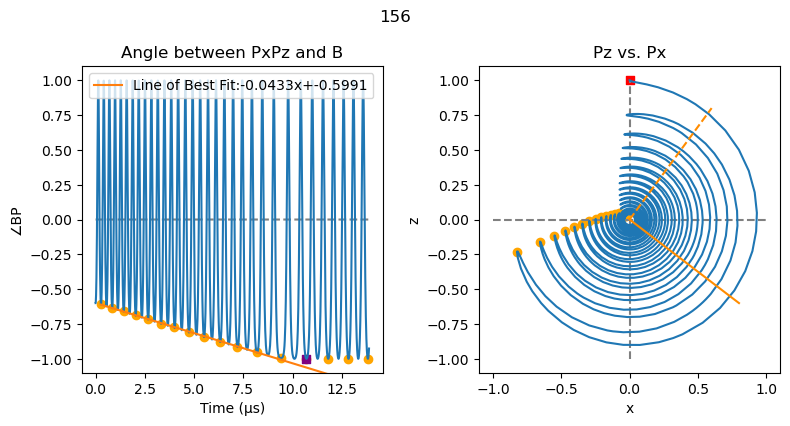

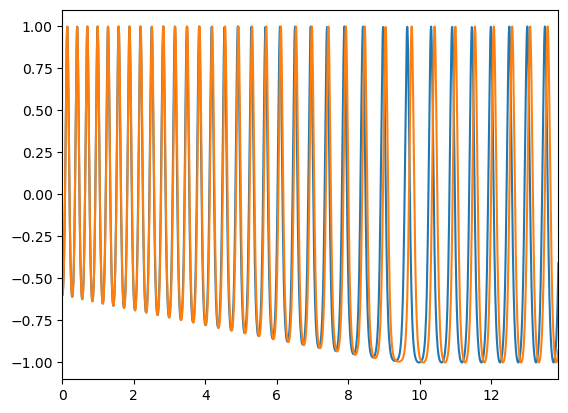

In [17]:
for i in eps_ind:
    y_data=model(times[i][pts[i]],co[0,i],co[1,i])
    
    plt.figure(figsize=(8.0,4.3))
#     fig.set_box_aspect(1) # fix later, make figures strict squares
    plt.subplot(1,2,1)
    plt.title('Angle between PxPz and B')
    plt.plot(times[i],[0]*len(times[i]),'--',color='gray')
    plt.plot(times[i],Bs[i][:,e_i])
    plt.scatter(times[i][pts[i]],Bs[i][pts[i],e_i],color='orange')
    plt.scatter(times[i][pts[i][switchs[i]]],Bs[i][pts[i][switchs[i]],e_i],marker='s',color='purple')
    # plt.xlim(10,17.5)
    plt.plot(times[i][pts[i]],y_data,label='Line of Best Fit:'+str(co[0,i])[:7]+'x+'+str(co[1,i])[:7])
    plt.xlabel('Time (μs)')
    plt.ylabel('∠BP')
    plt.ylim(-1.1,1.1)
    plt.legend(loc=2)
    
    plt.subplot(1,2,2)
    plt.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
    plt.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
    plt.title('Pz vs. Px')
    plt.plot(Pxs[i][:,e_i],Pzs[i][:,e_i])
#     plt.scatter(Px[cycle,e],Pz[cycle,e])
    plt.plot(B_lin*B[0],B_lin*B[2],label='B',color='darkorange')
    plt.plot(B_lin*-1*B[2],B_lin*B[0],'--',label='B⊥',color='darkorange')
    plt.scatter(Pxs[i][pts[i],e_i],Pzs[i][pts[i],e_i],color='orange')
    plt.scatter(Pxs[i][0,e_i],Pzs[i][0,e_i],color='red',marker='s')
    plt.xlabel('x')
    plt.ylabel('z')

    
    plt.suptitle(datas[i]['N_bins'])
    plt.tight_layout()
    
plt.figure()
plt.plot(times[0],Bs[0][:,e_i])
plt.plot(times[19],Bs[19][:,e_i])
plt.xlim(0,times[19][-1])
    

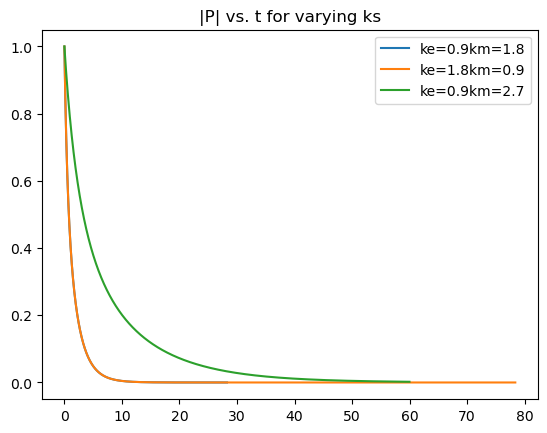

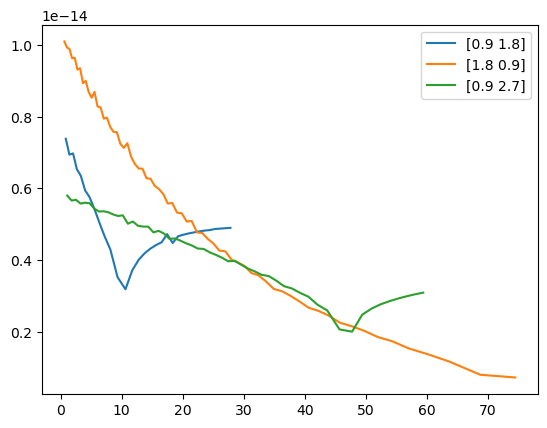

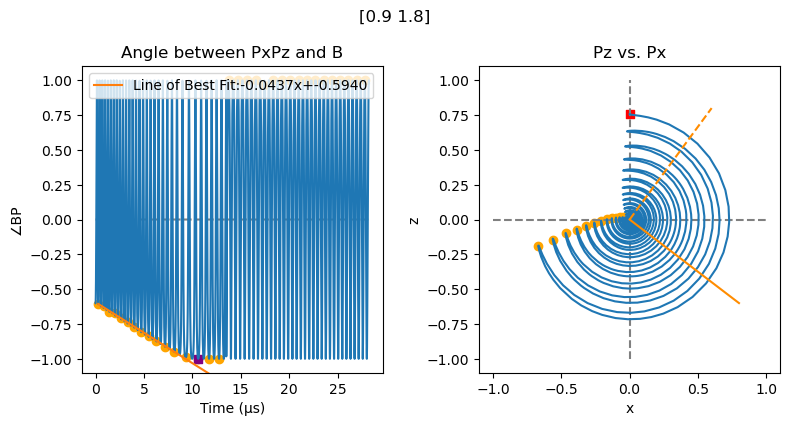

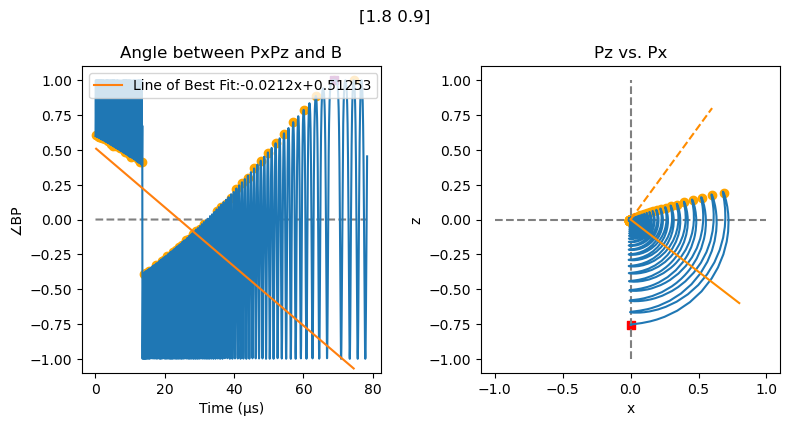

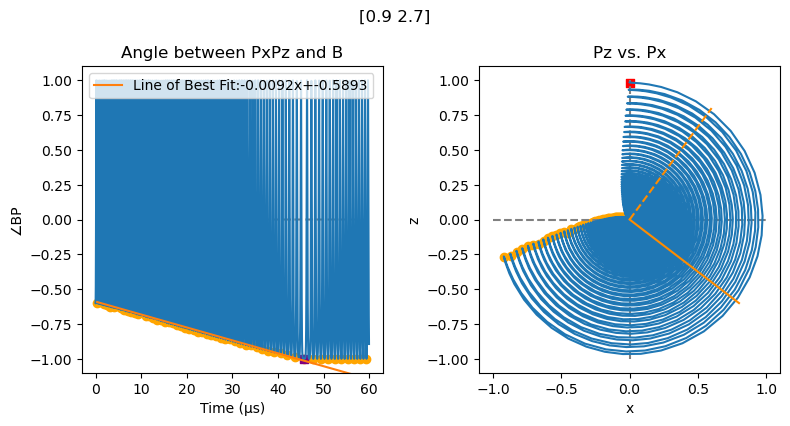

In [18]:
# plt.figure(figsize=(6,3))
# plt.subplot(1,2,1)
# plt.scatter(ks[0],np.abs(co[0,k_ind]))
# plt.title('a vs. ke')
# plt.xlabel('ke')
# plt.ylabel('a')
# plt.subplot(1,2,2)
# plt.scatter(ks[1],np.abs(co[0,k_ind]))
# plt.title('a vs. km')
# plt.xlabel('km')
# # plt.ylabel('Slope')
# plt.tight_layout()

# plt.figure(figsize=(6,3))
# plt.subplot(1,2,1)
# plt.scatter(ks[0],np.abs(co[1,k_ind]))
# plt.title('b vs. ke')
# plt.xlabel('ke')
# plt.subplot(1,2,2)
# plt.scatter(ks[1],np.abs(co[1,k_ind]))
# plt.title('b vs. km')
# plt.xlabel('km')
# # plt.ylabel('Slope')
# plt.tight_layout()


plt.figure()
plt.title('|P| vs. t for varying ks')
# plt.xlim(-1,30)
for i in range(len(k_ind)):
    plt.plot(times[k_ind[i]],radii[k_ind[i]][:,e_i],label='ke='+str(ks[0,i])+'km='+str(ks[1,i]))
plt.legend()

plt.figure()
for i in range(len(k_ind)):
    plt.plot(times[k_ind[i]][pts[k_ind[i]][1:]],afs[k_ind[i]],label=ks[:,i])
plt.legend()

e_i=45
for i in range(len(k_ind)):
    k=k_ind[i]
    y_data=model(times[k][pts[k]],co[0,k],co[1,k])
    
    
    plt.figure(figsize=(8.0,4.3))
#     fig.set_box_aspect(1) # fix later, make figures strict squares
    plt.subplot(1,2,1)
    plt.title('Angle between PxPz and B')
    plt.plot(times[k],[0]*len(times[k]),'--',color='gray')
    plt.plot(times[k],Bs[k][:,e_i])
    plt.scatter(times[k][pts[k]],Bs[k][pts[k],e_i],color='orange')
    plt.scatter(times[k][pts[k][switchs[k]]],Bs[k][pts[k][switchs[k]],e_i],marker='s',color='purple')
    # plt.xlim(10,17.5)
    plt.plot(times[k][pts[k]],y_data,label='Line of Best Fit:'+str(co[0,k])[:7]+'x+'+str(co[1,k])[:7])
    plt.xlabel('Time (μs)')
    plt.ylabel('∠BP')
    plt.ylim(-1.1,1.1)
    plt.legend(loc=2)
    
    plt.subplot(1,2,2)
    plt.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
    plt.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
    plt.title('Pz vs. Px')
    plt.plot(Pxs[k][:,e_i],Pzs[k][:,e_i])
#     plt.scatter(Px[cycle,e],Pz[cycle,e])
    plt.plot(B_lin*B[0],B_lin*B[2],label='B',color='darkorange')
    plt.plot(B_lin*-1*B[2],B_lin*B[0],'--',label='B⊥',color='darkorange')
    plt.scatter(Pxs[k][pts[k],e_i],Pzs[k][pts[k],e_i],color='orange')
    plt.scatter(Pxs[k][0,e_i],Pzs[k][0,e_i],color='red',marker='s')
    plt.xlabel('x')
    plt.ylabel('z')

    
    plt.suptitle(ks[:,i])
    plt.tight_layout()
    

In [19]:
# plt.figure(figsize=(6,3))
# plt.subplot(1,2,1)
# plt.scatter(ks[0]-ks[1],np.abs(co[0,k_ind]),label='a')
# plt.xlabel('a')
# plt.subplot(1,2,2)
# plt.scatter(ks[0]-ks[1],co[1,k_ind],label='b')
# plt.xlabel('b')
# plt.tight_layout()
# # plt.legend()

for i in range(len(k_ind)):
    dk=ks[0,i]-ks[1,i]
    eps=np.log(ks[0,i]/ks[1,i])
    eps=eps*3/dk
    print('ke=',ks[0,i],', km=',ks[1,i],':y=',co[0,k_ind[i]],'x+',co[1,k_ind[i]],' eps0=',eps)

ke= 0.9 , km= 1.8 :y= -0.0437235450197162 x+ -0.5940575664896388  eps0= 2.310490601866484
ke= 1.8 , km= 0.9 :y= -0.021235048026013673 x+ 0.5125373001468252  eps0= 2.310490601866484
ke= 0.9 , km= 2.7 :y= -0.009276120606846117 x+ -0.5893926171752604  eps0= 1.831020481113516


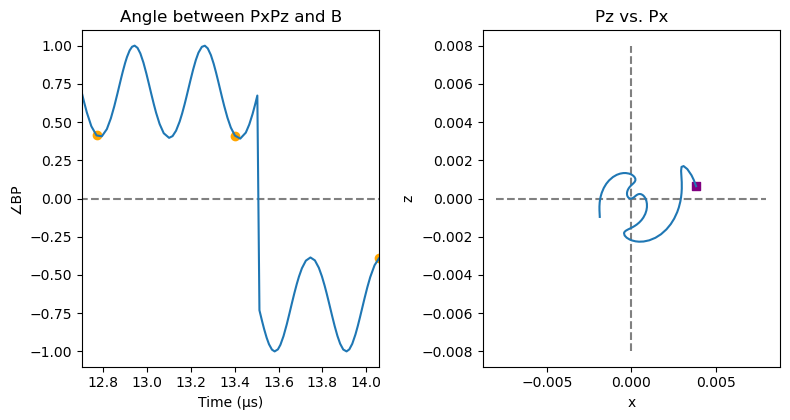

In [20]:
k=k_ind[1]
st=1350
end=1450
plt.figure(figsize=(8.0,4.3))
#     fig.set_box_aspect(1) # fix later, make figures strict squares
plt.subplot(1,2,1)
plt.title('Angle between PxPz and B')
plt.plot(times[k],[0]*len(times[k]),'--',color='gray')
plt.plot(times[k],Bs[k][:,e_i])
plt.scatter(times[k][pts[k]],Bs[k][pts[k],e_i],color='orange')
plt.scatter(times[k][pts[k][switchs[k]]],Bs[k][pts[k][switchs[k]],e_i],marker='s',color='purple')
    # plt.xlim(10,17.5)
plt.xlabel('Time (μs)')
plt.ylabel('∠BP')
plt.xlim(times[k][st],times[k][end])
plt.ylim(-1.1,1.1)
    
plt.subplot(1,2,2)
plt.plot(ax_lin*.008,[0]*len(ax_lin),'--',color='gray')
plt.plot([0]*len(ax_lin),ax_lin*.008,'--',color='gray')
plt.scatter(Pxs[k][st,e_i],Pzs[k][st,e_i],marker='s',color='purple')
plt.title('Pz vs. Px')
plt.plot(Pxs[k][st:end,e_i],Pzs[k][st:end,e_i])
#     plt.scatter(Px[cycle,e],Pz[cycle,e])
# plt.plot(B_lin*B[0],B_lin*B[2],label='B',color='darkorange')
# plt.plot(B_lin*-1*B[2],B_lin*B[0],'--',label='B⊥',color='darkorange')
# plt.scatter(Pxs[k][pts[k],e_i],Pzs[k][pts[k],e_i],color='orange')
# plt.scatter(Pxs[k][0,e_i],Pzs[k][0,e_i],color='red',marker='s')
plt.xlabel('x')
plt.ylabel('z')


plt.tight_layout()
    

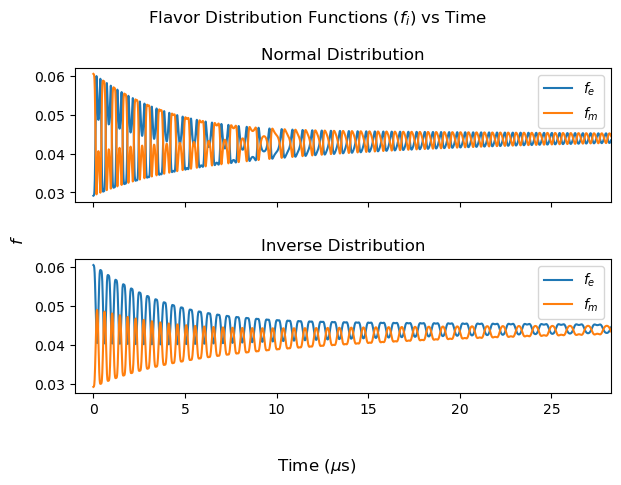

In [21]:
e=15
fig,(ax1,ax2)=plt.subplots(2,1,sharex=True)
fig.supylabel('$f$')
fig.supxlabel('Time ($\mu$s)')
fig.suptitle('Flavor Distribution Functions ($f_i$) vs Time')
fig.tight_layout()
ax1.set_xlim(-1,times[k_ind[0]][-1])

ax1.set_title('Normal Distribution')
ax1.set_box_aspect(0.25)
ax1.plot(times[k_ind[0]],fvs[k_ind[0]][0][:,e],label='$f_e$')
ax1.plot(times[k_ind[0]],fvs[k_ind[0]][1][:,e],label='$f_m$')
ax1.legend()

ax2.set_title('Inverse Distribution')
ax2.set_box_aspect(0.25)
ax2.plot(times[k_ind[1]],fvs[k_ind[1]][0][:,e],label='$f_e$')
ax2.plot(times[k_ind[1]],fvs[k_ind[1]][1][:,e],label='$f_m$')
ax2.legend()